### Start by loading in data

- UN text data
- GDP data
- climate associated words data

In [2]:
import os

"""
GETTING THE TEXT DATA FROM FOLDER DATA/TXT
"""



def get_text_data(output=False, N=False):
    """
    gets all the text data from the subfolders, can print it and you can limit the number of prints
    returns a dictionary with key the title of the file and value the text of the file
    """
    subfolders = []
    for folder in os.listdir('data/TXT'):
        if os.path.isdir(os.path.join('data/TXT', folder)):
            subfolders.append(folder)

    text_data = {}
    for folder in subfolders:
        for file in os.listdir(os.path.join('data/TXT', folder)):
            if file.endswith('.txt'):
                with open(os.path.join('data/TXT', folder, file), 'r') as f:
                    text_data[file] = f.read()
                    if output:
                        print(f"Title: {file}")
                        print(f"Text: {text_data[file]}")
                        print("\n")
                    if N and len(text_data) >= N:
                        return text_data
    return text_data

#test with first file
text_data = get_text_data()
print(text_data["ARG_01_1946.txt"])


At the resumption of the first session of the General Assembly, the Argentine delegation wishes to state its views on a number of questions.
Politics are determined by circumstances. Accordingly, in making these remarks, we do not renounce the right to take decisions in the light of events; but we nevertheless think it desirable to state here certain useful principles to serve as a guide for our actions. We hope that these remarks will be interpreted at their true value. We are not sceptics, but our relative optimism would be strengthened if we found that a spirit of conciliation were gaining ground. Otherwise, we should be obliged to resume complete freedom of action, and proceed in accordance with the circumstances and the interests of the country which we represent.
We are no friends of unanimity, which is wont to disguise undesirable, if not improper pressure. Even the hottest debates in the defence of conflicting points of view are not incompatible with the desire to reach a solut

In [17]:
import keyword
import regex as re

climate_words_dict = {"greenhouse_gases_and_emissions": [
        "carbon dioxide", "co2", "methane", "ch4", "nitrous oxide", "n2o",
        "fluorinated gases", "greenhouse effect", "carbon emissions",
        "scope 1 emissions", "scope 2 emissions", "scope 3 emissions",
        "carbon footprint", "carbon budget", "emission intensity", "flaring"
    ],
    "climate_science_and_phenomena": [
        "global warming", "surface temperature", "temperature anomaly",
        "radiative forcing", "albedo effect", "feedback loop", "tipping point",
        "keeling curve", "ocean acidification", "paleoclimatology", "antarctic ice sheet",
        "arctic sea ice", "permafrost thawing", "glacier retreat", "thermohaline circulation",
        "el nino", "la nina", "enso", "polar vortex"
    ],
    "extreme_weather_and_impacts": [
        "sea level rise", "storm surge", "coastal erosion", "flash drought",
        "megadrought", "heatwave", "heat dome", "wildfire", "forest fire",
        "tropical cyclone", "typhoon", "hurricane intensification",
        "biodiversity loss", "coral bleaching", "species extinction",
        "habitat fragmentation", "vector-borne disease", "water scarcity"
    ],
    "energy_and_technology": [
        "clean energy", "renewable energy", "solar photovoltaic", "wind turbine",
        "geothermal", "hydroelectric", "nuclear energy", "grid storage",
        "battery storage", "green hydrogen", "electrification", "heat pump",
        "electric vehicles", "ev adoption", "carbon capture and storage", "ccs",
        "direct air capture", "dac", "bioenergy"
    ],
    "policy_agreements_and_economics": [
        "ipcc", "cop28", "cop29", "cop30", "paris agreement", "unfccc",
        "nationally determined contributions", "ndc", "carbon pricing",
        "carbon tax", "cap and trade", "emissions trading system", "ets",
        "esg", "green finance", "loss and damage", "carbon border adjustment mechanism",
        "cbam", "net zero", "carbon neutrality", "climate justice"
    ],
    "adaptation_and_nature_solutions": [
        "climate adaptation", "climate resilience", "afforestation",
        "reforestation", "blue carbon", "mangrove restoration",
        "regenerative agriculture", "soil carbon sequestration",
        "rewilding", "sponge cities", "flood defense", "sea wall"
    ], 
    "school": [
        "school", "education", "curriculum", "teacher", "student",
        "classroom", "lesson", "learning", "teaching", "pedagogy", "university", "college", "schooling", "academic", "syllabus",
        "schooling", "academic", "syllabus", "instruction", "training",
        "schoolwork", "homework", "assignment", "exam", "test", "assessment", "grading", "evaluation", "classroom management",
        "school policy", "school"]
}

 


In [108]:
# load GDP.csv data 
import pandas as pd
gdp = pd.read_csv("data/GDP.csv")
gdp

list_of_countries = gdp['Country'].unique().tolist()
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Melt the wide GDP columns (1960-2022) into a key-value pair[cite: 3]
year_cols = [c for c in gdp.columns if c.isdigit()]
gdp_long = gdp.melt(
    id_vars=["Country Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="gdp",
)
gdp_long["Year"] = gdp_long["Year"].astype(int)

# 2. Set index for fast O(1) lookups: (country_code, year) -> gdp
gdp_lookup = gdp_long.set_index(["Country Code", "Year"])["gdp"]

In [131]:
#load pisa scores
pisa_df = pd.read_csv("data/average-performance-of-15-year-old-students-by-subject.csv")
pisa_df["average"] = pisa_df[["Mathematics", "Reading", "Science"]].mean(axis=1)
pisa_df_country = pisa_df.groupby("Entity").sum()
# display(pisa_df[pisa_df["Entity"]=="United States"], pisa_df[pisa_df["Entity"]=="Albania"])

pisa_df_filtered = pisa_df.groupby("Entity").filter(lambda g: len(g) > 7)
pisa_df_per_country = pisa_df_filtered.groupby(["Entity", "Year"]).sum()
# pisa_df_per_country


## EDA
from the dataframe of PISA scores, we can for example take Albania and USA. Albania does not have a record for each 3 years

## clean the text data and first scan

### speech data
---
We will use nltk module "stopwords" to remove stop words from the text data. 
The analysis will mainly focus on finding certain words in the text. By removing stop words, we do not have to match those words against words we are looking for. This will speed up the analysis. 
Furthermore, when doing a broader sentiment analysis, stop words will not be usefull and only make the text less information dense.

After removing stop words, we will quicky count the number of words per speech per country. This gives an indication of how long the speeches are and if they differ in lenght. This information is not needed for the final analysis, but helps with understanding the data.

### PISA score data
---
there are 88 countries in the PISA score data. If we only look at countries with entries from 2003 to 2022, there are 31 remaining. It is not needed to drop those countries, since we will predict PISA based on speeches from that country the year before. 

In [ ]:
import nltk
nltk.download('stopwords')

def speech_set(text_data):
    """
    replaces dict value with set instead of list
    """
    for key in text_data:
        text_data[key] = set(text_data[key].split())
    return text_data

def speech_set_no_stopwords(text_data):
    """
    removes stopwords (input should be set so call speech_set first)
    """
    stopwords = set(nltk.corpus.stopwords.words('english'))
    
    for key in text_data:
        text_data[key] = text_data[key] - stopwords
    return text_data



text = speech_set(text_data)
text = speech_set_no_stopwords(text)



[nltk_data] Downloading package stopwords to /Users/jacob/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# each key starts with 3 letter code. 
# generate new dict with key as 3 letter code and as value the number of words that appear in text (keys can have same 3 letter as beginning, so add those to the total)
word_count = {}
for key in text:
    token = key[:3]
    if token not in word_count:
        word_count[token] = []
    word_count[token].append(len(text[key]))

for key in word_count:
    word_count[key] = sum(word_count[key])/len(word_count[key])

sorted_word_count = sorted(word_count.items(), key=lambda x:x[1], reverse=True)

### counting the number of mentions of climate associated words
Combining the data from the UN speeches and the climate associated words, we can count the number of mentions of climate associated words per speech per country per year. We will store it by country, topic and year. 

In [115]:
from locale import normalize
from turtle import rt
import pandas as pd
import re

records = []

for country_speech_year, speech_tokens in text.items():

    if "DS_Store" in country_speech_year:
        continue  
    
    country = country_speech_year[:3]
    year = int(country_speech_year[-8:-4])
   
    speech_str = " ".join(speech_tokens)
    
    for topic, word_list in climate_words_dict.items():
        pattern = re.compile(r"\b(" + "|".join(re.escape(w) for w in word_list) + r")\b", re.IGNORECASE)
        matches = pattern.findall(speech_str)
        
        if matches:
            records.append({
                "country": country,
                "year": year,
                "topic": topic,
                "mention_count": len(matches),
                "matched_words": list(set(m.lower() for m in matches)),
                "total_words": len(speech_tokens),
                "normalised_mention_count": len(matches) / len(speech_tokens) if len(speech_tokens) > 0 else 0
            })

df_keywords = pd.DataFrame(records)

In [125]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


def get_speech_mentions(
    df_keywords, country_code, start_year, end_year, topic="school"
):
    """Calculates total topic mentions for a country between start_year and end_year (exclusive)."""
    mask = (
        (df_keywords["country"] == country_code)
        & (df_keywords["year"] >= start_year)
        & (df_keywords["year"] < end_year)
        & (df_keywords["topic"] == topic)
    )
    return df_keywords.loc[mask, "mention_count"].sum()


def build_regression_dataset(
    pisa_df, df_keywords, years_back=1, topic="school", drop_zero_mentions=True
):
    """Pairs historical speech mention counts with corresponding PISA scores."""
    data = []

    # Map country name to country code once to avoid repeated index slicing
    country_to_code = (
        pisa_df["Code"].groupby(level="Entity").first().to_dict()
    )

    for country, year in pisa_df.index:
        country_code = country_to_code.get(country)
        if not country_code:
            continue

        start_year = year - years_back
        total_mentions = get_speech_mentions(
            df_keywords, country_code, start_year, year, topic=topic
        )

        if drop_zero_mentions and total_mentions == 0:
            continue

        pisa_score = pisa_df.loc[(country, year), "average"]
        if pd.notna(pisa_score):
            data.append({"mentions": total_mentions, "pisa_score": pisa_score})

    if not data:
        return np.array([]).reshape(-1, 1), np.array([])

    df_dataset = pd.DataFrame(data)
    X = df_dataset[["mentions"]].values
    y = df_dataset["pisa_score"].values
    return X, y


def plot_regression(X, y, model, years_back, topic="school"):
    """Plots scatter points and the fitted OLS regression line."""
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, alpha=0.6, edgecolors="k", label="Observations")

    # Sort X for a clean continuous line plot
    X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_pred = model.predict(X_line)

    plt.plot(X_line, y_pred, color="red", linewidth=2, label="OLS Fit")
    plt.xlabel(f"Total Mentions of '{topic}' (Past {years_back} Years)")
    plt.ylabel("PISA Average Score")
    plt.title(
        f"PISA Score vs. '{topic}' Mentions ({years_back}-Year Window)\n"
        f"R² = {model.score(X, y):.3f} | Slope = {model.coef_[0]:.2f}"
    )
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


def regress_pisa_on_speech(
    years_back, pisa_df, df_keywords, topic="school", show_plot=True
):
    """Main pipeline to extract data, fit linear regression, and evaluate."""
    X, y = build_regression_dataset(
        pisa_df, df_keywords, years_back=years_back, topic=topic
    )

    if len(X) == 0:
        print(
            f"No matching data points found for topic='{topic}' with years_back={years_back}."
        )
        return None, None, None

    model = LinearRegression().fit(X, y)

    if show_plot:
        plot_regression(X, y, model, years_back, topic=topic)

    return model, X, y

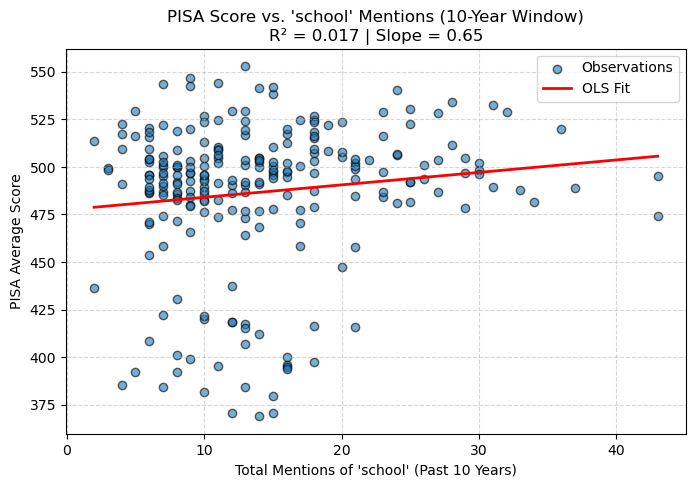

In [132]:
# Run for a 10-year window
model, X, y = regress_pisa_on_speech(
    years_back=10,
    pisa_df=pisa_df_per_country,
    df_keywords=df_keywords,
    topic="school",
)

In [8]:
# now we will count how often each country names other countries using country_list as check
records = []
for country_speech_year, speech_tokens in text.items():
    if "DS_Store" in country_speech_year:
        continue  
    
    country = country_speech_year[:3]
    year = int(country_speech_year[-8:-4])
    
    speech_str = " ".join(speech_tokens)
    
    for other_country in list_of_countries:
        if other_country.lower() in speech_str.lower():
            records.append({
                "country": country,
                "year": year,
                "mentioned_country": other_country
            })  

df_mentions = pd.DataFrame(records)

In [15]:
# rework the df such that it lists how often a country is mentioned by another one (instead of who's mentioning whom)
# df_mentions_count = df_mentions.groupby(['mentioned_country', 'country'])
df_mentions[df_mentions["year"]==2020]

,country,year,mentioned_country
32992,ISL,2020,Belarus
32993,ISL,2020,Georgia
32994,ISL,2020,Iceland
32995,ISL,2020,Libya
32996,ISL,2020,Ukraine
...,...,...,...
33916,AND,2020,World
33917,BHR,2020,Bahrain
33918,BHR,2020,Israel
33919,BHR,2020,Libya


In [ ]:
from numpy import disp


df_keywords_topic = df_keywords.groupby(['country', 'topic']).sum('mention_count').drop(columns=['year'])

df_keywords_total = df_keywords.groupby(['country']).sum('mention_count').drop(columns=['year'])


df_pivot = df_keywords_topic.pivot_table(
    index='country',
    columns='topic',
    values='mention_count',
    aggfunc='sum',
    fill_value=0
)
df_pivot



topic,adaptation_and_nature_solutions,energy_and_technology,extreme_weather_and_impacts,greenhouse_gases_and_emissions,policy_agreements_and_economics
country,,,,,
AFG,0,2,1,0,0
AGO,0,2,0,0,1
ALB,0,4,0,0,0
AND,0,2,0,0,2
ARE,0,0,0,0,2
...,...,...,...,...,...
YMD,0,1,0,0,0
YUG,0,0,0,2,0
ZAF,0,0,0,0,2


In [ ]:
display(df_keywords_total, df_keywords_topic, df_keywords_total[df_keywords_total['mention_count'] >= 10])

,mention_count
country,
AFG,3
AGO,3
ALB,4
AND,4
ARE,2
...,...
YMD,1
YUG,2
ZAF,2


mention_count
country topic                                         
AFG     energy_and_technology                        2
        extreme_weather_and_impacts                  1
AGO     energy_and_technology                        2
        policy_agreements_and_economics              1
ALB     energy_and_technology                        4
...                                                ...
YUG     greenhouse_gases_and_emissions               2
ZAF     policy_agreements_and_economics              2
ZMB     energy_and_technology                        2
        policy_agreements_and_economics              3
ZWE     policy_agreements_and_economics              1

[320 rows x 1 columns]

,mention_count
country,
BFA,10
DMA,12
FJI,12
FSM,26
ISL,25
KEN,13
KHM,11
LCA,10
MDG,10


In [ ]:
# we will start with regressi